# Map back airway sputum annotations to the combined object

Imports

In [5]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
COMB_V= 'refined-clustered'
COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{COMB_V}.h5ad'

NEW_COMB_V = 'refined-clustered'
NEW_COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{NEW_COMB_V}.h5ad'

SUB_OBJ = "ambiguous"
SUB_OBJ_V = 'reclustered'
SUB_OBJ_PATH = MAIN_DIR / 'data' / 'sub' / SUB_OBJ / 'h5ad' / f'{SUB_OBJ}-{SUB_OBJ_V}.h5ad'

In [6]:
# load comb obj
comb = sc.read_h5ad(COMB_PATH)

In [12]:
# load airway epi obj
sub = sc.read_h5ad(SUB_OBJ_PATH)

Get all the cell names and annotations

In [13]:
sub_ann = sub.obs[["leiden","reclustered_ct"]].copy()

In [14]:
sub_ann = sub_ann.rename(columns={
    "leiden": f"{SUB_OBJ}_leiden_n10_0.2",
    "reclustered_ct": "ann_lvl_3_refined",
})

sub_ann

,Amb_leiden_n10_0.2,ann_lvl_3_refined
cell_id,,
SLIDE04_14,1,Amb
SLIDE04_15,0,Neut
SLIDE04_63,1,Amb
SLIDE04_64,1,Amb
SLIDE04_82,1,Amb
...,...,...
SLIDE02_426912,0,Neut
SLIDE02_426945,1,Amb
SLIDE02_426959,1,Amb


Map back

In [15]:
# Add the airway Leiden clusters; non-airway cells will be NaN
comb.obs[f"{SUB_OBJ}_leiden_n10_0.2"] = (
    sub_ann[f"{SUB_OBJ}_leiden_n10_0.2"]
    .reindex(comb.obs.index)
)

# Start with the original annotation for every cell
comb.obs["ann_lvl_3_refined"] = comb.obs["ann_lvl_3_refined"].astype(str)

# Replace annotations only for cells present in sub_ann
common_cells = comb.obs.index.intersection(sub_ann.index)

comb.obs.loc[common_cells, "ann_lvl_3_refined"] = (
    sub_ann.loc[common_cells, "ann_lvl_3_refined"].astype(str)
)

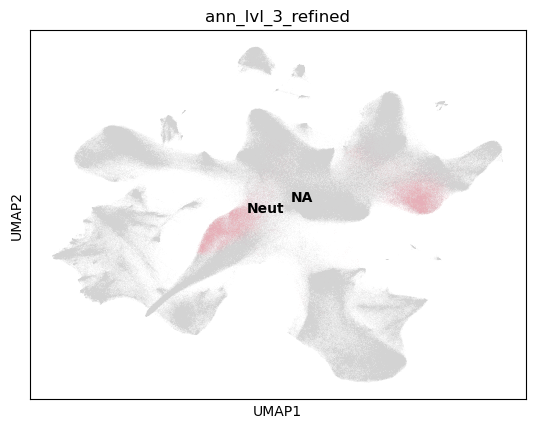

In [18]:
sc.pl.umap(
    comb, 
    color=["ann_lvl_3_refined"],
    groups=['Neut'],
    legend_loc="on data"
)

Save the annotated object

In [17]:
comb.write_h5ad(NEW_COMB_PATH)